In [1]:
import os
import numpy as np
from scipy.io import loadmat
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [62]:
def load_data(dir_func = '../../highRes_resting/derivatives/correlations/sub-50/smallGap/WithinLayer/FC_matrix.npy', dir_SC = '../../highRes_resting/derivatives/correlations/structuralMatrix/adjacency_matrix.npy'):

    sc = np.load(dir_SC)
    rs = np.load(dir_func)
    W = np.clip(sc, a_min=0, a_max=None)

    return W, rs


def compute_normalized_laplacian(W: np.ndarray):
    """
    Compute symmetric normalized Laplacian L = I - D^{-1/2} W D^{-1/2}.
    Returns L and the symmetrically normalized weight matrix.
    """
    d = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    W_symm = D_inv_sqrt @ W @ D_inv_sqrt
    L = np.eye(W.shape[0]) - W_symm
    return L, W_symm


def laplacian_eigendecomp(L: np.ndarray):
    """
    Perform eigendecomposition, sort ascending, return eigenvalues and eigenvectors.
    """
    lambdas, U = np.linalg.eigh(L)
    idx = np.argsort(lambdas)
    return lambdas[idx], U[:, idx]


def weighted_zero_crossings(U: np.ndarray, W: np.ndarray, threshold: float = 1.0):
    """
    Count weighted zero crossings per eigenvector: for each pair (i,j),
    if signs differ and W[i,j]>threshold, increment.
    Returns array of length n_harmonics.
    """
    n, k = U.shape
    wZC = np.zeros(k, dtype=int)
    for u in range(k):
        uu = U[:, u]
        count = 0
        for i in range(n - 1):
            for j in range(i + 1, n):
                if uu[i] * uu[j] < 0 and W[i, j] > threshold:
                    count += 1
        wZC[u] = count
    return wZC


def project_and_compute_psd(U: np.ndarray, X_RS: np.ndarray):
    """
    Project z-scored fMRI signals onto structural harmonics, compute PSD:
      X_hat_L[:, :, s] = U^T @ zX_RS[:, :, s]
      PSD = mean(abs(X_hat_L)^2, axis=time)
    Returns PSD (n_harmonics x n_subjects).
    """
    # z-score each ROI timecourse along time axis
    zX = zscore(X_RS, axis=1, ddof=0)
    X_hat = U.T @ zX
    power = np.abs(X_hat) ** 2
    PSD = np.mean(power, axis=1)  # average across time
    return PSD


def plot_zero_crossings(wZC: np.ndarray):
    plt.figure()
    plt.plot(wZC)
    plt.title('Weighted Zero Crossings')
    plt.xlabel('Harmonic index')
    plt.ylabel('Weighted zero crossings')
    plt.show()


def plot_psd(lambdas: np.ndarray, PSD: np.ndarray):
    # avg = np.mean(PSD, axis=1)
    # std_dev = np.std(PSD, axis=1)
    # lower = avg - std_dev
    # upper = avg + std_dev
    # valid = (np.max(PSD, axis=1) > 0) & (np.min(PSD, axis=1) > 0) & (avg > 0)
    plt.figure()
    # plt.fill_between(lambdas[valid], lower[valid], upper[valid], alpha=0.3)
    plt.plot(lambdas, PSD)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Harmonic frequency')
    plt.ylabel('Power')
    plt.title('Energy Spectral Density')
    plt.show()


def compute_cutoff_frequency(lambdas: np.ndarray, PSD: np.ndarray, percentile: float = 0.5) -> float:
    """
    Determine cutoff lambda where cumulative PSD reaches given percentile of total power.
    """
    mPSD = PSD
    total_area = np.trapz(mPSD)
    cum = np.cumsum(mPSD)
    idx = np.searchsorted(cum, percentile * total_area)
    return lambdas[min(idx, len(lambdas) - 1)]


In [46]:
W, X_RS = load_data()

In [47]:
assert np.all(np.isfinite(W)), "W contains inf or NaN!"
assert np.all(W >= 0), "W has negative weights—make sure this is intended."

In [48]:
L, W_symm = compute_normalized_laplacian(W)



In [49]:
lambdas, U = laplacian_eigendecomp(L)
print(W)

[[1.         0.24201993 0.71862493 ... 0.         0.         0.        ]
 [0.24201993 1.         0.70784539 ... 0.79122675 0.37395994 0.        ]
 [0.71862493 0.70784539 1.         ... 0.26959565 0.         0.        ]
 ...
 [0.         0.79122675 0.26959565 ... 1.         0.72179405 0.06833279]
 [0.         0.37395994 0.         ... 0.72179405 1.         0.6461777 ]
 [0.         0.         0.         ... 0.06833279 0.6461777  1.        ]]


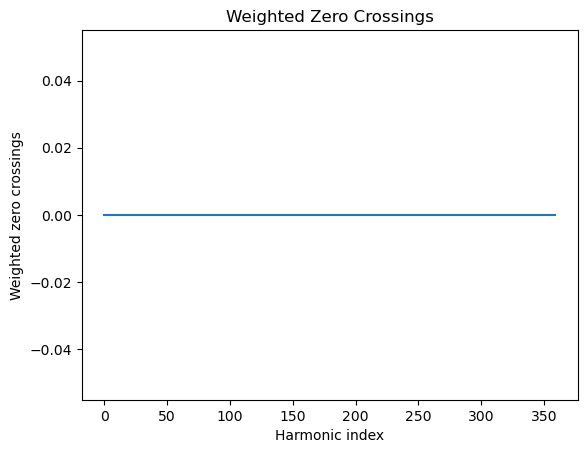

In [50]:
wZC = weighted_zero_crossings(U, W)
plot_zero_crossings(wZC)


In [51]:
X_RS_deep  = X_RS[:360,:360]
X_RS_middle = X_RS[360:720,360:720]
X_RS_sup = X_RS[720:1080,720:1080]

PSD_deep = project_and_compute_psd(U, X_RS_deep)
PSD_middle = project_and_compute_psd(U, X_RS_middle)
PSD_sup = project_and_compute_psd(U, X_RS_sup)


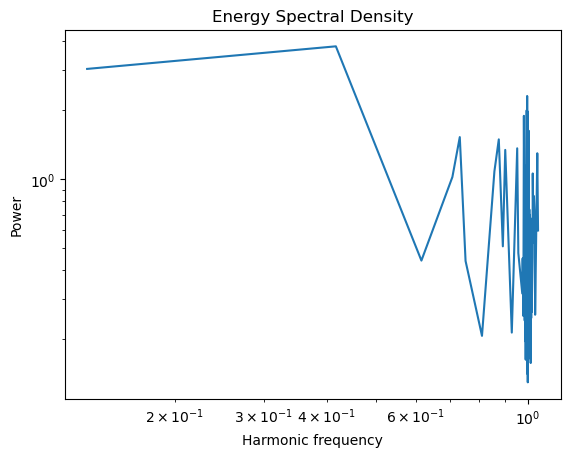

In [60]:
plot_psd(lambdas[1:], PSD_deep[1:])

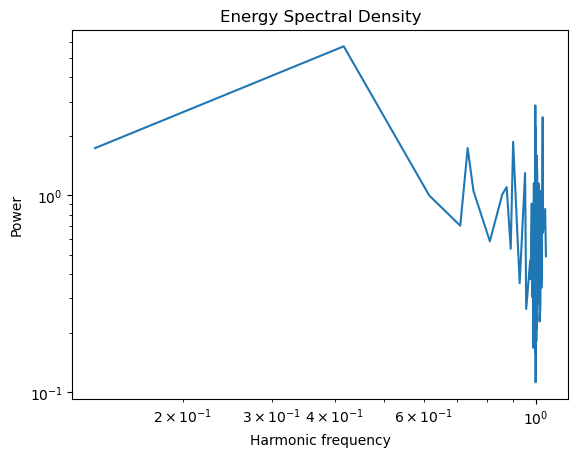

In [57]:
plot_psd(lambdas[1:], PSD_middle[1:])

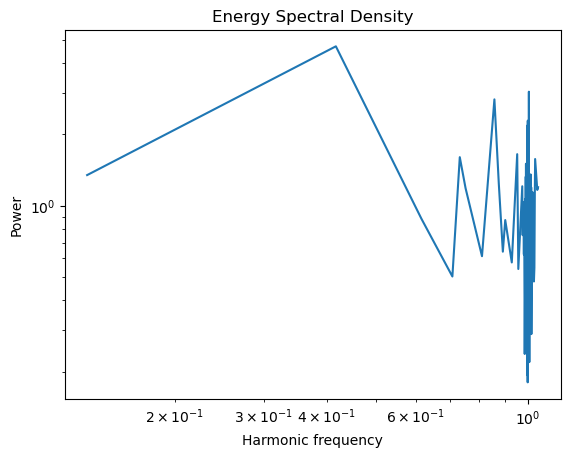

In [58]:
plot_psd(lambdas[1:], PSD_sup[1:])

In [64]:
compute_cutoff_frequency(lambdas[1:], PSD_sup[1:])

0.9961740772277666

In [66]:
compute_cutoff_frequency(lambdas[1:], PSD_deep[1:])

0.9999725678161433

In [85]:
def compute_coupling_decoupling(X_RS, PSD):

    n_roi = U.shape[0]
    mPSD = PSD
    AUCTOT = np.trapz(mPSD[:n_roi])
    AUC = 0.0
    i = 0
    while AUC < AUCTOT / 2 and i < len(mPSD):
        AUC = np.trapz(mPSD[:i])
        i += 1
    NN = i - 1  # number of low-frequency harmonics
    NNL = n_roi - NN  # number of high-frequency harmonics

        # Split structural harmonics into low/high frequency components
    M = np.fliplr(U)
    Vlow = np.zeros_like(M)
    Vhigh = np.zeros_like(M)
    Vhigh[:, :NNL] = M[:, :NNL]  # high-frequency (decoupled)
    Vlow[:, -NN:] = M[:, -NN:]    # low-frequency (coupled)

    # GRAPH SIGNAL ANALYSIS
    data = zscore(X_RS, axis=1, ddof=0)
    n_roi, T = X_RS.shape

    N_c = np.zeros((n_roi))
    N_d = np.zeros((n_roi))
        
    X_hat = M.T @ data
    X_c = Vlow @ X_hat
    X_d = Vhigh @ X_hat
    X_all = M @ X_hat  # reconstruct full signal for norm check

    for r in range(n_roi):
        N_c[r] = np.linalg.norm(X_c[r, :])
        N_d[r] = np.linalg.norm(X_d[r, :])

    mean_c = np.mean(N_c, axis=0)  # average coupling per ROI
    mean_d = np.mean(N_d, axis=0)  # average decoupling per ROI
    print(f'Mean coupling (mean_c): {mean_c}')
    print(f'Mean decoupling (mean_d): {mean_d}')

    print(f"Index: {mean_d/mean_c}")

In [87]:
compute_coupling_decoupling(X_RS_deep, PSD_deep)

Mean coupling (mean_c): 14.534823681255542
Mean decoupling (mean_d): 10.84445991370575
Index: 0.7461019240082717


In [88]:
compute_coupling_decoupling(X_RS_middle, PSD_middle)

Mean coupling (mean_c): 14.350424591241628
Mean decoupling (mean_d): 11.352043188322282
Index: 0.7910597429466079


In [89]:
compute_coupling_decoupling(X_RS_sup, PSD_sup)

Mean coupling (mean_c): 14.01659489090115
Mean decoupling (mean_d): 11.793726694079396
Index: 0.8414116827857581
